# Classification — Theory and Practice

#### Block 2 of Phase 1 · ML-Notes-and-Projects

This notebook continues the study log started in `01_LinearRegression`, now moving to **classification**: predicting a categorical (here, binary) response instead of a continuous one. As before, it combines theory from *An Introduction to Statistical Learning* (ISLP, Chapter 4) with the practical approach from *Hands-On Machine Learning* (HOML).

### Dataset

We use the **UCI Heart Disease dataset** (Cleveland Clinic Foundation, 1988), a classic and well-documented dataset in clinical machine learning: 303 patients, 13 clinical predictors (age, sex, chest pain type, blood pressure, cholesterol, etc.), and a binary target indicating the pressence of heart disease.

This is a natural fit for classification (unlike `SalePrice` in Block 1, there's no meaningful continuous version of "has heart disease or not"), and the medical context makes the classification metrics we'll cover feel like real decisions rather than abstract formulas.

Dataset Source: Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X.

### Goals of this notebook

1. Understand **why linear regression is a poor fit** for a binary response, and why it motivates a different modeling approach.
2. Implement **Logistic Regression** (first with a single predictor, then with multiple predictors), understanding the sigmoid function, log-odds, and Maximum Likelihood Estimation (MLE).
3. Learn to properly **evaluate a classifier**: confusion matrix, precision, recall, F1-score, ROC curve and AUC. Understand whyh accuracy alone can be misleading.
4. Exxplore how moving the **decision threshold** changes the precision/recall trade-off, and when that matters in practice.
5. Briefly contrast Logistin Regression with **LDA/QDA** (ISLP, Chapter 4.4), two alternative classification approaches.

## 0. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score, f1_score, roc_curve, roc_auc_score,
    precision_recall_curve
)

sns.set_theme(style="whitegrid")
np.random.seed(42)

## 1. First Look at the Data

In [7]:
df = pd.read_csv("heart-disease.csv")
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


All 13 predictors plus the `target` column are numeric, with **no missing values**. However, several of these "numeric" columns are actually **encoded categorical variables** (e.g. `cp` = chest pain has 4 categories: 0-3; `thal` similarly). Once we reach the multiple logistic regression section, we'll treat them accordingly.

**Column reference** (from the UCI documentation):

|**Column**|**Meaning**|
|---|---|
|`age`|Age in years|
|`sex`|1 = male, 0 = female|
|`cp`|Chest pain type (0-3, categorical)|
|`trestbps`|Resting blood pressure (mm Hg)|
|`chol`|Serum cholesterol (mg/dl)|
|`fbs`|Fasting blood sugar > 120 mg/dl (1 = True)|
|`restecg`|Resting ECG results (0-2, categorical)|
|`thalach`|Maximum heart rate achieved|
|`exang`|Exersice-induced angina (1 = yes)|
|`oldpeak`|ST depression induced by exercise relative to rest|
|`slope`|Slope of the peak exercise ST segment (0-2, categorical)|
|`ca`|Number of major vessels colored by fluoroscopy (0-4)|
|`thal`|Thalassemia (0-3, categorical)|
|`target`|**1 = heart disease present, 0 = absent** (our response variable)|

In [9]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

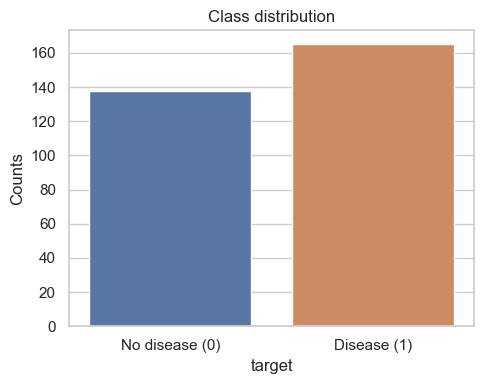

In [10]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="target", hue="target", legend=False)
plt.xticks([0,1], ["No disease (0)", "Disease (1)"])
plt.title("Class distribution")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

The classes are mildly imbalanced (165 positives vs. 138 negative, about 54%/46%), not severely enough to require special resampling techniques but enough to make it a genuinely useful example later when we discuss why accuracy alone can be a misleading metric.

## 2. Why Not Just Use Linear Regression?

Before introducing logistic regresion, it's worth seeing concretely why we need a different at all — ISLP (Chapter 4.1) motivates this well, and it's more convincing to see it rather than just being told.

Suppose we tried to predict `target` (0 or 1) directly with ordinary linear regression, using a single predictor: `thalach` (maximum heart rate achieved). Linear regression would fit a straight line through the 0/1 points and treat the output as a probability.

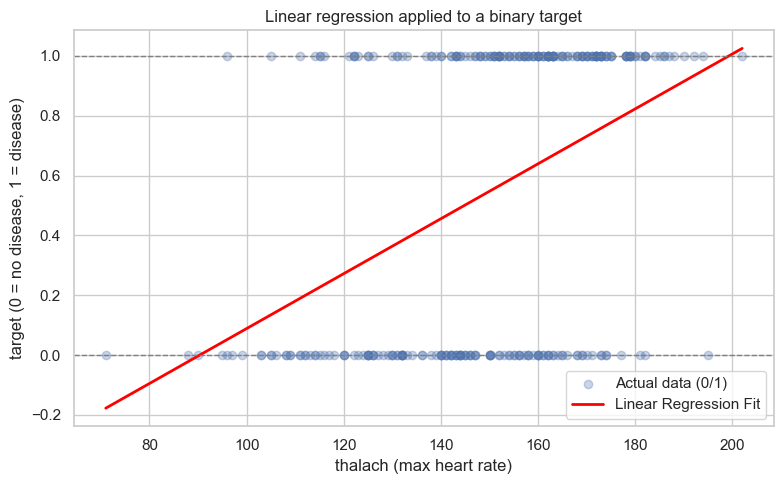

In [12]:
X_demo = df[["thalach"]].values
y_demo = df["target"].values

lin_reg_demo = LinearRegression()
lin_reg_demo.fit(X_demo, y_demo)

x_range = np.linspace(X_demo.min(), X_demo.max(), 100).reshape(-1, 1)
y_range_pred = lin_reg_demo.predict(x_range)

plt.figure(figsize=(8,5))
plt.scatter(X_demo, y_demo, alpha=0.3, label="Actual data (0/1)")
plt.plot(x_range, y_range_pred, color="red", linewidth=2, label="Linear Regression Fit")
plt.axhline(y=0, color="gray", linestyle="--", linewidth=1)
plt.axhline(y=1, color="gray", linestyle="--", linewidth=1)
plt.xlabel("thalach (max heart rate)")
plt.ylabel("target (0 = no disease, 1 = disease)")
plt.title("Linear regression applied to a binary target")
plt.legend()
plt.tight_layout()
plt.show()

Two problems are immediately visible:

1. **The predicted values are not probabilities**. For low `thalach` values, the line predicts numbers above 1; nothing stops linear regression from producing values outside the `[0,1]` range, which makes no sense as "the probability of heart disease".
2. **The relationship is forced to be a straight line**, when the actual pattern in the data is more like a threshold or S-shaped transition between two classes — for very low or very high `thalach`, we'd want the model to be confidently close to 0 or 1, not just extrapolating forever.

What we actually want is a function that takes any real-valued input and squashes it into the (0,1) range, behaving like a genuine probability. This is exactly what the sigmoid (logistic) function does, and it's the foundation of logistic regression.